# Question 2: Who Should We Prioritize In Our Outreach

## Assignment
> Using the selection criteria you made, we have manually picked about 100 sellers at random to check if they were indeed businesses, and for the ones we were unsure of, we gave them a call. It turns out that 83% were business sellers, good job!
>
> It is now March 2025, and the product development for the SMB bundles has completed. We are ready to launch them. The bundles come in two flavors:
>
> - Basic: You will both get you a “Verified seller” icon, a professional seller page, extra pictures for more visibility.
> - Plus: You will get all advantages of Basic, plus extra visibility stickers, and on every ad you get a photo gallery with a link to your other ads.
>
> We have attached a 5% sample of identified prospects. The data consists of monthly usage statistics per category per seller, showing the ads and the features they have used, of the period 2023-2024. In total there are approximately 80k of these prospects in Marktplaats. In our first batch we want to reach out to the 20k sellers that we believe have most potential at this point in time.
>
> To make sure we prioritize the right sellers, we ask you to analyze the data set. We want to call the highest potentials. Provide explorative analyses, and give a recommendation on what type of users to call, and clearly answering why. Any differentiation between which sellers we offer which bundle?
>
> P.S. For this case we only included the SYI sellers, not the Pro sellers, and we excluded cars and jobs ads.


## Exploratory Data Analysis

### Dataset Structure

The CSV contains 129,501 rows, 18 columns, 3,840 sellers, 24 monthly periods, and 32 categories.

Grain: **one row = one seller (`USER_ID`, Seller ID) + one month (`FTR_MONTH`, Month) + one category (`CATEGORY_NAME`, Category)**

Column reference:

| Column | English meaning |
|---|---|
| `USER_ID` | Seller ID |
| `FTR_MONTH` | Month |
| `CATEGORY_NAME` | Category |
| `N_FREE_AD_INSERTIONS` | Number of free ad/listing insertions |
| `N_PAID_AD_INSERTIONS` | Number of paid ad/listing insertions |
| `FEE_PAID_AD_INSERTIONS` | Fees paid for paid ad/listing insertions |
| `N_AD_RENEWALS` | Number of ad renewals |
| `FEE_AD_RENEWALS` | Fees paid for ad renewals |
| `N_DAGTOPPERS` | Number of Dagtoppers; paid day-topper / daily top-placement visibility features |
| `FEE_DAGTOPPERS` | Fees paid for Dagtoppers |
| `N_HOMEPAGE` | Number of homepage placements |
| `FEE_HOMEPAGE` | Fees paid for homepage placements |
| `N_PAID_URL` | Number of paid URL/link features |
| `FEE_PAID_URL` | Fees paid for paid URL/link features |
| `N_AD_UPCALLS` | Number of ad upcalls; likely ad bumps / move-ad-up features |
| `FEE_AD_UPCALLS` | Fees paid for ad upcalls |
| `N_URGENCY` | Number of urgency labels/stickers |
| `FEE_URGENCY` | Fees paid for urgency labels/stickers |

Other than `N_FREE_AD_INSERTIONS` (free ad/listing insertions), the activity metrics represent commercial listing or visibility products. Actual spend should be measured with the `FEE_...` columns (fee columns), because a feature count can still have zero fee if it was included, discounted, or credited.

To compare sellers, we need to aggregate this raw month-category data to seller level. Useful seller-level features will include total ads, total paid features, total fees, active months, category breadth, recent activity, and trends over time.


In [1]:
import importlib
import functions

functions = importlib.reload(functions)

from functions import (
    AD_COUNT_COLUMNS,
    FEE_COLUMNS,
    FEATURE_COUNT_COLUMNS,
    PLOT_COLORS,
    Q2_CATEGORY_COLUMN,
    Q2_DATE_COLUMN,
    Q2_NUMERIC_COLUMNS,
    Q2_USER_COLUMN,
    add_q2_row_metrics,
    add_horizontal_bar_labels,
    format_display_table,
    eur,
    format_eur_axis,
    format_number_axis,
    format_percent_axis,
    pd,
    plot_q2_method_overlap_venn,
    plt,
    read_q2_data,
    readable_category_label,
    readable_metric_label,
    q2_bundle_recommendation_summary,
    q2_method_comparison,
    q2_selection_summary,
    score_q2_outreach_readiness,
    seller_level_q2_summary,
    set_plot_style,
    top_categories,
)

set_plot_style()

df = add_q2_row_metrics(read_q2_data())

overview = {
    "rows": len(df),
    "columns": df.shape[1],
    "unique_sellers": df[Q2_USER_COLUMN].nunique(),
    "unique_months": df[Q2_DATE_COLUMN].nunique(),
    "first_month": df[Q2_DATE_COLUMN].min(),
    "last_month": df[Q2_DATE_COLUMN].max(),
    "unique_categories": df[Q2_CATEGORY_COLUMN].nunique(),
}

overview


{'rows': 129501,
 'columns': 24,
 'unique_sellers': 3840,
 'unique_months': 24,
 'first_month': Timestamp('2023-01-01 00:00:00'),
 'last_month': Timestamp('2024-12-01 00:00:00'),
 'unique_categories': 32}

### Basic Checks

First, I check the structure and data quality before building seller-level features. Simple pass/fail checks are shown as short sentences; tables and charts are reserved for comparisons that help prioritization.


In [2]:
dimension_cols = [Q2_USER_COLUMN, Q2_DATE_COLUMN, Q2_CATEGORY_COLUMN]
count_cols = AD_COUNT_COLUMNS + FEATURE_COUNT_COLUMNS
fee_cols = FEE_COLUMNS
metric_cols = Q2_NUMERIC_COLUMNS


In [3]:
missing_values = df.isna().sum().sum()
duplicate_grain_rows = df.duplicated(dimension_cols).sum()
negative_metric_values = (df[metric_cols] < 0).sum().sum()

if missing_values == duplicate_grain_rows == negative_metric_values == 0:
    print(
        "Data quality check: no missing values, no duplicate seller-month-category rows, "
        "and no negative metric values."
    )
else:
    print(
        f"Data quality check: {missing_values} missing values, "
        f"{duplicate_grain_rows} duplicate seller-month-category rows, "
        f"and {negative_metric_values} negative metric values."
    )


Data quality check: no missing values, no duplicate seller-month-category rows, and no negative metric values.


In [4]:
metric_summary = pd.DataFrame(
    {
        "Column": metric_cols,
        "Metric": [readable_metric_label(column) for column in metric_cols],
        "Total": df[metric_cols].sum().values,
        "Non-zero Rows": (df[metric_cols] > 0).sum().values,
        "Non-zero Row %": ((df[metric_cols] > 0).mean() * 100).round(1).values,
    }
).sort_values("Total", ascending=False).reset_index(drop=True)

metric_summary_display = metric_summary.copy()
metric_summary_display["Total"] = metric_summary_display.apply(
    lambda row: eur(row["Total"]) if row["Column"] in fee_cols else f"{row['Total']:,.0f}",
    axis=1,
)
metric_summary_display


,Column,Metric,Total,Non-zero Rows,Non-zero Row %
0,N_FREE_AD_INSERTIONS,Free Ad Insertions,"1,051,612",88923,68.7
1,N_AD_RENEWALS,Ad Renewals,"791,611",65896,50.9
2,FEE_PAID_URL,Paid URL,"€380,885",1706,1.3
3,FEE_AD_RENEWALS,Ad Renewals,"€374,518",17912,13.8
4,N_PAID_AD_INSERTIONS,Paid Ad Insertions,"368,786",8633,6.7
5,FEE_PAID_AD_INSERTIONS,Paid Ad Insertions,"€198,692",8633,6.7
6,FEE_DAGTOPPERS,Dagtoppers,"€167,624",10566,8.2
7,FEE_HOMEPAGE,Homepage,"€87,613",1214,0.9
8,N_PAID_URL,Paid URL,"86,868",5087,3.9
9,N_AD_UPCALLS,Ad Upcalls,"71,537",12977,10.0


In [5]:
df["commercial_uses"] = df["paid_ad_insertions"] + df["total_feature_uses"]

row_metric_summary = df[["total_ad_insertions", "commercial_uses", "total_fees"]].describe().round(2)
row_metric_summary = row_metric_summary.rename(columns=readable_metric_label)
row_metric_summary_display = row_metric_summary.copy()
row_metric_summary_display["Total Fees"] = [
    f"{value:,.0f}" if index == "count" else f"€{value:,.2f}"
    for index, value in row_metric_summary_display["Total Fees"].items()
]
row_metric_summary_display


,Total Ad Insertions,Commercial Uses,Total Fees
count,129501.00,129501.00,"129,501"
mean,10.97,10.69,€9.88
std,283.75,453.98,"€1,041.24"
min,0.00,0.00,€0.00
25%,0.00,0.00,€0.00
50%,1.00,1.00,€0.00
75%,3.00,3.00,€1.07
max,60622.00,121172.00,"€373,856.85"


In [6]:
monthly_summary = (
    df.groupby(Q2_DATE_COLUMN, as_index=False)
    .agg(
        sellers=(Q2_USER_COLUMN, "nunique"),
        rows=(Q2_USER_COLUMN, "size"),
        categories=(Q2_CATEGORY_COLUMN, "nunique"),
        total_ad_insertions=("total_ad_insertions", "sum"),
        commercial_uses=("commercial_uses", "sum"),
        total_fees=("total_fees", "sum"),
    )
)


In [7]:
category_summary = top_categories(df, top_n=df[Q2_CATEGORY_COLUMN].nunique())


In [8]:
seller_summary = seller_level_q2_summary(df)

seller_summary_display = seller_summary.drop(
    columns=[Q2_USER_COLUMN, "first_month", "last_month", "has_paid_visibility", "has_paid_ads"]
)
seller_summary_display = seller_summary_display.rename(columns=readable_metric_label)
seller_summary_describe = seller_summary_display.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)
seller_summary_describe_display = seller_summary_describe.copy()
for column in ["Total Fees", "Average Fees per Active Month"]:
    seller_summary_describe_display[column] = [
        f"{value:,.0f}" if index == "count" else f"€{value:,.2f}"
        for index, value in seller_summary_describe_display[column].items()
    ]
seller_summary_describe_display


,Categories,Total Ad Insertions,Free Ad Insertions,Paid Ad Insertions,Total Feature Uses,Paid Marketplace Actions,Paid Visibility Uses,Total Fees,Active Months,Average Ads per Active Month,Average Fees per Active Month
count,3840.00,3840.00,3840.00,3840.00,3840.00,3840.00,3840.00,"3,840",3840.00,3840.00,"3,840"
mean,6.39,369.90,273.86,96.04,264.58,360.62,58.43,€333.30,12.75,18.63,€17.74
std,5.57,5063.77,1520.17,4831.48,3083.84,7771.67,1176.91,"€6,782.24",8.45,232.53,€310.11
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,€0.00,1.00,0.00,€0.00
25%,2.00,6.00,4.00,0.00,3.00,4.00,1.00,€2.71,5.00,1.22,€0.34
50%,5.00,26.00,21.00,1.00,18.00,22.00,4.00,€24.04,12.00,2.60,€2.59
75%,9.00,108.00,92.00,4.00,82.00,93.00,15.00,€108.18,22.00,7.18,€8.84
90%,15.00,441.20,409.00,15.00,341.10,387.10,61.00,€346.49,24.00,22.64,€23.99
95%,18.00,1012.35,962.20,34.00,800.05,840.15,137.05,€751.56,24.00,47.96,€44.12
99%,23.00,4936.32,4744.03,193.61,3645.20,3892.76,658.21,"€3,579.78",24.00,234.16,€149.16


### Key Visuals

These charts focus on the comparisons that matter most for outreach prioritization: activity over time, category concentration, which paid products drive spend, and how concentrated seller value is.


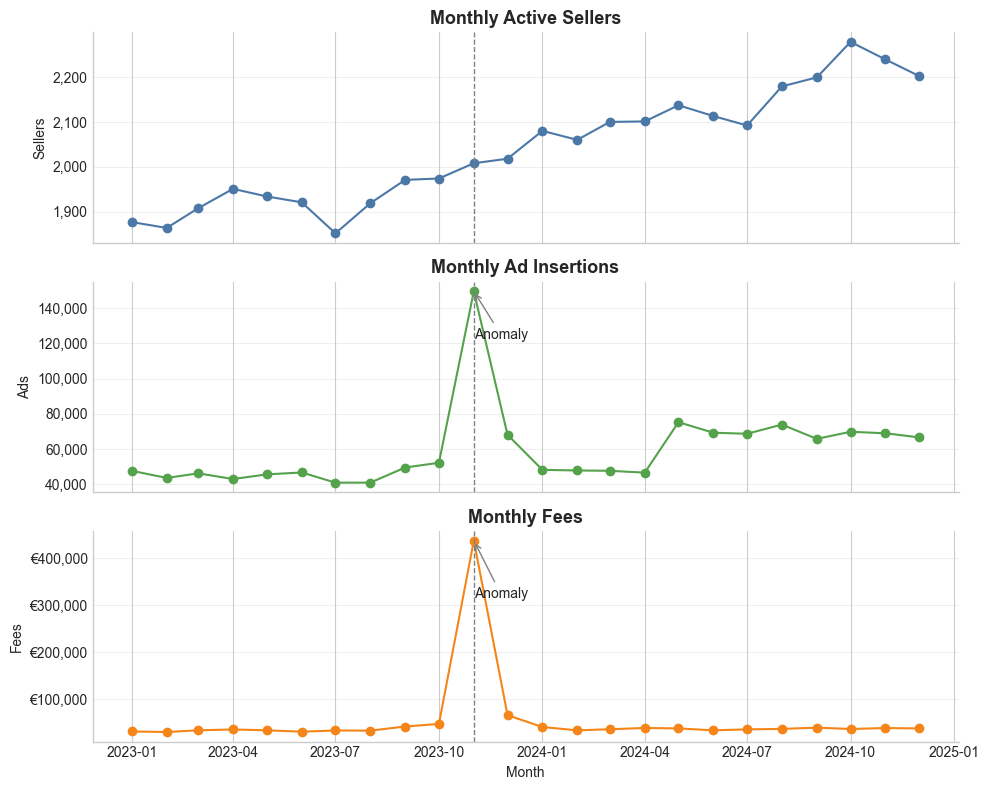

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
anomaly_month = pd.Timestamp("2023-11-01")

axes[0].plot(monthly_summary[Q2_DATE_COLUMN], monthly_summary["sellers"], marker="o", color=PLOT_COLORS["primary"])
axes[0].set_title("Monthly Active Sellers")
axes[0].set_ylabel("Sellers")

axes[1].plot(monthly_summary[Q2_DATE_COLUMN], monthly_summary["total_ad_insertions"], marker="o", color=PLOT_COLORS["success"])
axes[1].set_title("Monthly Ad Insertions")
axes[1].set_ylabel("Ads")

axes[2].plot(monthly_summary[Q2_DATE_COLUMN], monthly_summary["total_fees"], marker="o", color=PLOT_COLORS["secondary"])
axes[2].set_title("Monthly Fees")
axes[2].set_ylabel("Fees")
axes[2].set_xlabel("Month")

for ax in axes:
    ax.axvline(anomaly_month, color="gray", linestyle="--", linewidth=1)
    format_number_axis(ax, axis="y")
    ax.grid(axis="y", alpha=0.3)
format_eur_axis(axes[2], axis="y")

anomaly_ads = monthly_summary.loc[monthly_summary[Q2_DATE_COLUMN].eq(anomaly_month), "total_ad_insertions"].iloc[0]
anomaly_fees = monthly_summary.loc[monthly_summary[Q2_DATE_COLUMN].eq(anomaly_month), "total_fees"].iloc[0]
axes[1].annotate(
    "Anomaly",
    xy=(anomaly_month, anomaly_ads),
    xytext=(anomaly_month, anomaly_ads * 0.82),
    arrowprops={"arrowstyle": "->", "color": "gray"},
)
axes[2].annotate(
    "Anomaly",
    xy=(anomaly_month, anomaly_fees),
    xytext=(anomaly_month, anomaly_fees * 0.72),
    arrowprops={"arrowstyle": "->", "color": "gray"},
)

fig.tight_layout()


### Spike Check

The November 2023 spike is not annual seasonality. It is mostly explained by one seller-category row: seller `65950787` in `Auto-onderdelen (Auto Parts)`. This looks like a real row in the data, not an aggregation mistake, but it is an anomaly candidate and should not dominate outreach scoring.

Similar patterns elsewhere in the data:

- Seller `65950787` continues to have very high monthly paid ad insertions in `Auto-onderdelen (Auto Parts)` during 2024, often above 25,000 ads, but without the same huge paid URL fee spike.
- Seller `92181632` has a smaller one-off paid insertion spike in `Huis en Inrichting (Home and Interior)` in September 2023: 6,750 ad insertions and 5,813 paid ad insertions.
- Seller `48833205` has repeated high-fee rows across multiple categories, mainly from homepage placements and ad upcalls, with very few ad insertions.
- Sellers `36465400` and `37262181` have very high renewal counts in `Cd's en Dvd's (CDs and DVDs)`, but near-zero fees. These are volume anomalies, not revenue spikes.


In [10]:
anomaly_seller_id = 65950787
anomaly_category = "Auto-onderdelen"
anomaly_row = df[
    df[Q2_USER_COLUMN].eq(anomaly_seller_id)
    & df[Q2_DATE_COLUMN].eq(anomaly_month)
    & df[Q2_CATEGORY_COLUMN].eq(anomaly_category)
].iloc[0]

anomaly_month_totals = monthly_summary.loc[monthly_summary[Q2_DATE_COLUMN].eq(anomaly_month)].iloc[0]

anomaly_detail = pd.DataFrame(
    [
        {
            "Seller ID": anomaly_seller_id,
            "Month": anomaly_month.strftime("%Y-%m"),
            "Category": readable_category_label(anomaly_category),
            "Paid Ad Insertions": anomaly_row["N_PAID_AD_INSERTIONS"],
            "Paid URL Features": anomaly_row["N_PAID_URL"],
            "Paid URL Fees": anomaly_row["FEE_PAID_URL"],
            "Total Fees": anomaly_row["total_fees"],
            "Share of Monthly Ads": anomaly_row["total_ad_insertions"] / anomaly_month_totals["total_ad_insertions"],
            "Share of Monthly Fees": anomaly_row["total_fees"] / anomaly_month_totals["total_fees"],
        }
    ]
)

anomaly_detail.style.format(
    {
        "Paid Ad Insertions": "{:,.0f}",
        "Paid URL Features": "{:,.0f}",
        "Paid URL Fees": "€{:,.0f}",
        "Total Fees": "€{:,.0f}",
        "Share of Monthly Ads": "{:.1%}",
        "Share of Monthly Fees": "{:.1%}",
    }
)


,Seller ID,Month,Category,Paid Ad Insertions,Paid URL Features,Paid URL Fees,Total Fees,Share of Monthly Ads,Share of Monthly Fees
0,65950787,2023-11,Auto-onderdelen (Auto Parts),"60,622","60,550","€361,604","€373,857",40.5%,85.4%


In [11]:
monthly_without_anomaly_seller = (
    df[df[Q2_USER_COLUMN].ne(anomaly_seller_id)]
    .groupby(Q2_DATE_COLUMN, as_index=False)
    .agg(
        sellers=(Q2_USER_COLUMN, "nunique"),
        total_ad_insertions=("total_ad_insertions", "sum"),
        total_fees=("total_fees", "sum"),
    )
)

spike_comparison = monthly_summary[[Q2_DATE_COLUMN, "total_ad_insertions", "total_fees"]].merge(
    monthly_without_anomaly_seller[[Q2_DATE_COLUMN, "total_ad_insertions", "total_fees"]],
    on=Q2_DATE_COLUMN,
    suffixes=("_all", "_excluding_seller"),
)
spike_comparison["Ads Explained by Seller"] = (
    spike_comparison["total_ad_insertions_all"] - spike_comparison["total_ad_insertions_excluding_seller"]
)
spike_comparison["Fees Explained by Seller"] = (
    spike_comparison["total_fees_all"] - spike_comparison["total_fees_excluding_seller"]
)
spike_comparison["Ads Explained %"] = spike_comparison["Ads Explained by Seller"] / spike_comparison["total_ad_insertions_all"]
spike_comparison["Fees Explained %"] = spike_comparison["Fees Explained by Seller"] / spike_comparison["total_fees_all"]

spike_comparison_display = spike_comparison[
    spike_comparison[Q2_DATE_COLUMN].between(pd.Timestamp("2023-09-01"), pd.Timestamp("2024-01-01"))
].copy()
spike_comparison_display["Month"] = spike_comparison_display[Q2_DATE_COLUMN].dt.strftime("%Y-%m")
spike_comparison_display = spike_comparison_display.rename(
    columns={
        "total_ad_insertions_all": "Ads: All Sellers",
        "total_ad_insertions_excluding_seller": f"Ads: Excluding Seller {anomaly_seller_id}",
        "total_fees_all": "Fees: All Sellers",
        "total_fees_excluding_seller": f"Fees: Excluding Seller {anomaly_seller_id}",
    }
)[
    [
        "Month",
        "Ads: All Sellers",
        f"Ads: Excluding Seller {anomaly_seller_id}",
        "Ads Explained by Seller",
        "Ads Explained %",
        "Fees: All Sellers",
        f"Fees: Excluding Seller {anomaly_seller_id}",
        "Fees Explained by Seller",
        "Fees Explained %",
    ]
]

def highlight_anomaly_month(row):
    return ["background-color: #fff3cd" if row["Month"] == "2023-11" else "" for _ in row]

spike_comparison_display.style.apply(highlight_anomaly_month, axis=1).format(
    {
        "Ads: All Sellers": "{:,.0f}",
        f"Ads: Excluding Seller {anomaly_seller_id}": "{:,.0f}",
        "Ads Explained by Seller": "{:,.0f}",
        "Ads Explained %": "{:.1%}",
        "Fees: All Sellers": "€{:,.0f}",
        f"Fees: Excluding Seller {anomaly_seller_id}": "€{:,.0f}",
        "Fees Explained by Seller": "€{:,.0f}",
        "Fees Explained %": "{:.1%}",
    }
)


,Month,Ads: All Sellers,Ads: Excluding Seller 65950787,Ads Explained by Seller,Ads Explained %,Fees: All Sellers,Fees: Excluding Seller 65950787,Fees Explained by Seller,Fees Explained %
8,2023-09,"49,404","49,404",0,0.0%,"€40,974","€40,940",€35,0.1%
9,2023-10,"52,110","52,110",0,0.0%,"€46,449","€46,397",€52,0.1%
10,2023-11,"149,732","89,110","60,622",40.5%,"€437,987","€64,062","€373,926",85.4%
11,2023-12,"68,023","66,890","1,133",1.7%,"€65,185","€53,428","€11,758",18.0%
12,2024-01,"48,071","45,639","2,432",5.1%,"€39,869","€33,507","€6,362",16.0%


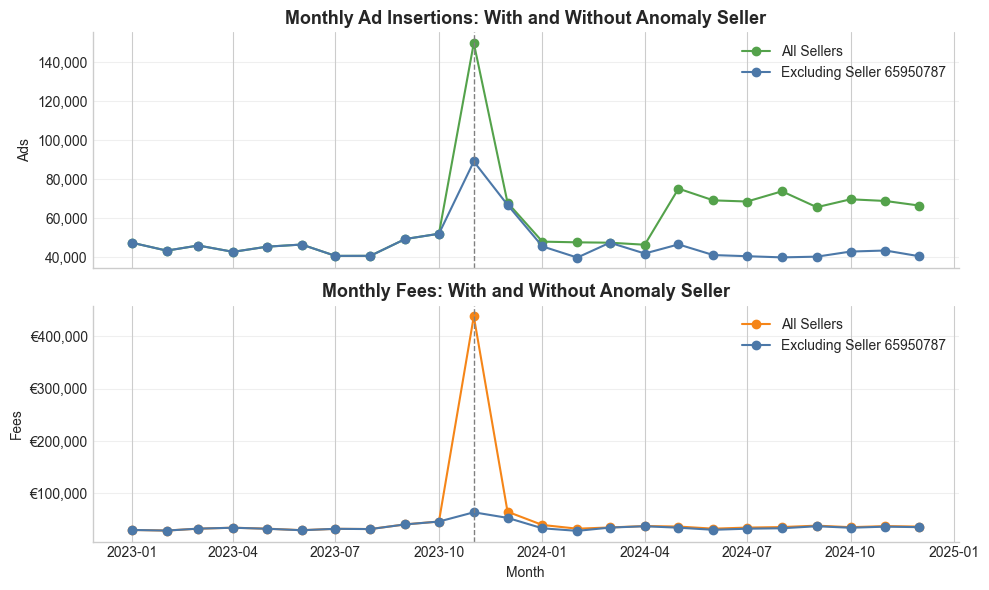

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(monthly_summary[Q2_DATE_COLUMN], monthly_summary["total_ad_insertions"], marker="o", label="All Sellers", color=PLOT_COLORS["success"])
axes[0].plot(monthly_without_anomaly_seller[Q2_DATE_COLUMN], monthly_without_anomaly_seller["total_ad_insertions"], marker="o", label=f"Excluding Seller {anomaly_seller_id}", color=PLOT_COLORS["primary"])
axes[0].set_title("Monthly Ad Insertions: With and Without Anomaly Seller")
axes[0].set_ylabel("Ads")

axes[1].plot(monthly_summary[Q2_DATE_COLUMN], monthly_summary["total_fees"], marker="o", label="All Sellers", color=PLOT_COLORS["secondary"])
axes[1].plot(monthly_without_anomaly_seller[Q2_DATE_COLUMN], monthly_without_anomaly_seller["total_fees"], marker="o", label=f"Excluding Seller {anomaly_seller_id}", color=PLOT_COLORS["primary"])
axes[1].set_title("Monthly Fees: With and Without Anomaly Seller")
axes[1].set_ylabel("Fees")
axes[1].set_xlabel("Month")

for ax in axes:
    ax.axvline(anomaly_month, color="gray", linestyle="--", linewidth=1)
    format_number_axis(ax, axis="y")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
format_eur_axis(axes[1], axis="y")

fig.tight_layout()


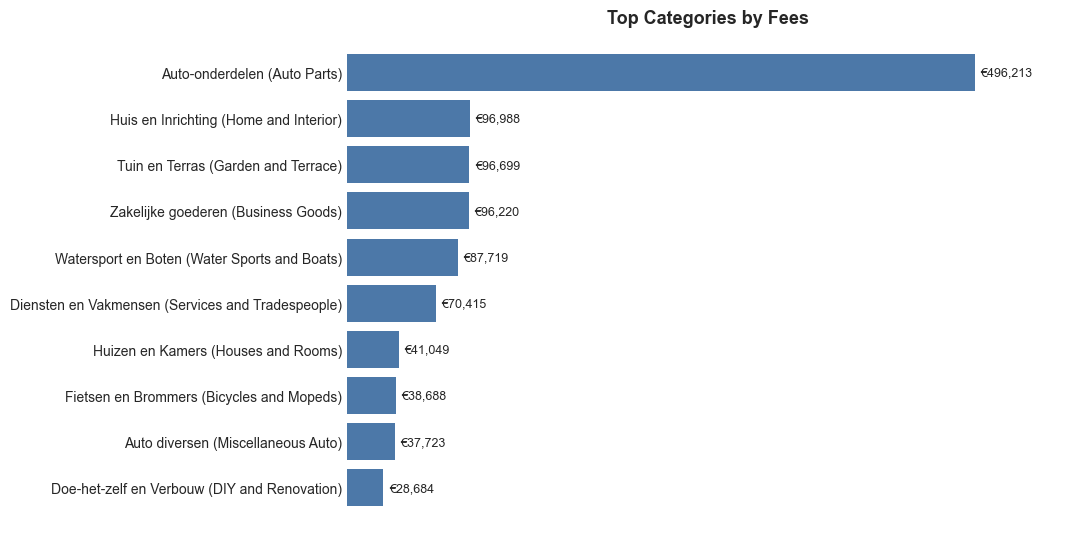

In [13]:
top_category_fees = category_summary.head(10).sort_values("total_fees")
top_category_labels = top_category_fees[Q2_CATEGORY_COLUMN].map(readable_category_label)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(top_category_labels, top_category_fees["total_fees"], color=PLOT_COLORS["primary"])
ax.set_title("Top Categories by Fees")
add_horizontal_bar_labels(ax, fmt="€{:,.0f}")
ax.grid(False)
ax.margins(x=0.15)
ax.set_xlabel("")
ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.tick_params(axis="y", left=False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.tight_layout()
fig.subplots_adjust(left=0.33)


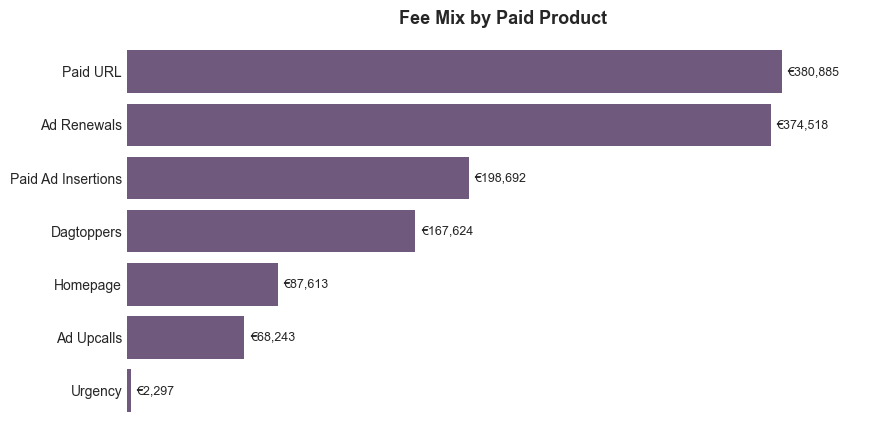

In [14]:
fee_mix = df[fee_cols].sum().sort_values()
fee_mix.index = [readable_metric_label(column) for column in fee_mix.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(fee_mix.index, fee_mix.values, color="#6F5A7E")
ax.set_title("Fee Mix by Paid Product")
add_horizontal_bar_labels(ax, fmt="€{:,.0f}")
ax.grid(False)
ax.margins(x=0.15)
ax.set_xlabel("")
ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.tick_params(axis="y", left=False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.tight_layout()


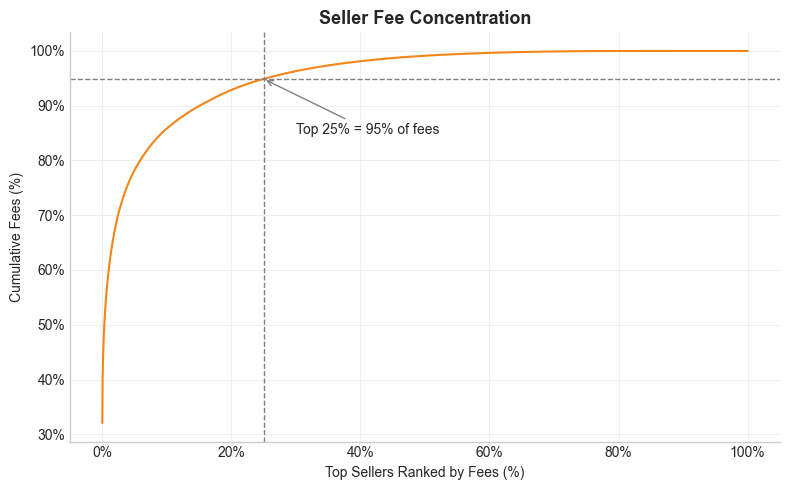

In [15]:
seller_fee_rank = seller_summary.sort_values("total_fees", ascending=False).reset_index(drop=True)
seller_fee_rank["seller_rank_pct"] = (seller_fee_rank.index + 1) / len(seller_fee_rank) * 100
seller_fee_rank["cumulative_fee_pct"] = seller_fee_rank["total_fees"].cumsum() / seller_fee_rank["total_fees"].sum() * 100
top_25_fee_share = seller_fee_rank.loc[seller_fee_rank["seller_rank_pct"].ge(25), "cumulative_fee_pct"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(seller_fee_rank["seller_rank_pct"], seller_fee_rank["cumulative_fee_pct"], color=PLOT_COLORS["secondary"])
ax.axvline(25, color="gray", linestyle="--", linewidth=1)
ax.axhline(top_25_fee_share, color="gray", linestyle="--", linewidth=1)
ax.annotate(
    f"Top 25% = {top_25_fee_share:.0f}% of fees",
    xy=(25, top_25_fee_share),
    xytext=(30, top_25_fee_share - 10),
    arrowprops={"arrowstyle": "->", "color": "gray"},
)
ax.set_title("Seller Fee Concentration")
ax.set_xlabel("Top Sellers Ranked by Fees (%)")
ax.set_ylabel("Cumulative Fees (%)")
format_percent_axis(ax, axis="both")
ax.grid(alpha=0.3)

fig.tight_layout()


### Initial Findings

- The data quality looks clean for this first pass: no missing values, no duplicated seller-month-category rows, and no negative metric values.
- Seller activity is highly skewed. The median seller has 26 total ad insertions and €24.04 in fees, while the top 1% have thousands of ad insertions and much higher spend.
- Free ad insertions are the largest activity metric, followed by ad renewals and paid ad insertions.
- Paid URL, ad renewals, paid ad insertions, Dagtoppers, and homepage placements are the largest fee sources.
- `Auto-onderdelen` is the largest category by total fees and paid feature usage in this sample, even though cars ads themselves are excluded.
- The next step is to turn this into seller-level features so outreach can be ranked by potential value and bundle fit.


## Outreach Prioritization Method

- **Goal:** rank bundle readiness, not just historical spend.
- **Why:** fee-only ranking can miss sellers who are active, growing, broad-category, or already familiar with paid products.
- **Approach:** convert each signal to a seller percentile rank, then average the six scores.
- **Next step:** after outreach starts, use response / conversion outcomes to train a supervised model.

| Signal | Purpose | Definition | Score |
|---|---|---|---|
| Recent paid usage | Current paid-product need / activity | Paid marketplace actions in the last 6 months | Percentile rank |
| Consistency | Reliability as a subscription candidate | Number of months with seller activity across 2023-2024 | Percentile rank |
| Category breadth | Fit for professional seller page / bundle value | Number of categories used across 2023-2024 | Percentile rank |
| Recent growth | Momentum | Recent paid usage vs prior 6 months, with +1 smoothing | Percentile rank |
| Total fees | Historical willingness to pay | Total fees paid across 2023-2024 | Percentile rank |
| Paid product breadth | Familiarity with multiple paid products | Number of distinct paid marketplace product types used across 2023-2024 | Percentile rank |

- **Scoring:** each signal is measured on a 0-100 percentile scale, so signals with different raw units can be averaged.
- **Effect:** very large raw values do not dominate the score; they only place a seller higher in that signal's ranking.



The comparison table below shows the **average signal score** for selected sellers. Each signal score is a percentile rank from 0 to 100, so higher means the selected cohort is stronger on that signal.


In [16]:
scored_sellers = score_q2_outreach_readiness(df, seller_summary)
method_comparison = q2_method_comparison(scored_sellers)

format_display_table(
    method_comparison,
    euro_columns=["Total fees"],
    decimal_columns=[
        "Avg recent paid usage score",
        "Avg consistency score",
        "Avg category breadth score",
        "Avg recent growth score",
        "Avg total fees score",
        "Avg paid product breadth score",
        "Avg readiness score",
    ],
)


,Method,Selected Sellers,Total fees,Avg recent paid usage score,Avg consistency score,Avg category breadth score,Avg recent growth score,Avg total fees score,Avg paid product breadth score,Avg readiness score
0,Readiness score,960,"€1,080,806",82.5,77.4,71.8,59.7,76.6,77.4,74.2
1,Total-fee rank,960,"€1,214,488",71.4,73.9,52.0,45.3,87.5,74.1,67.4


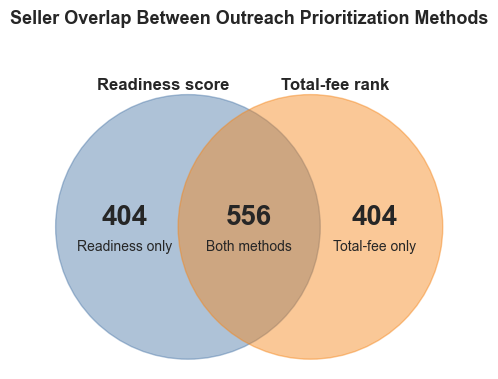

In [17]:
fig, ax = plot_q2_method_overlap_venn(scored_sellers)


In [18]:
selection_summary = q2_selection_summary(scored_sellers).rename(
    columns={
        "selected_by": "Selected By",
        "sellers": "Sellers",
        "total_fees": "Total Fees",
        "recent_total_fees": "Recent Fees",
        "avg_active_months": "Avg Active Months",
        "avg_recent_paid_usage": "Avg Recent Paid Usage",
        "avg_categories": "Avg Categories",
        "avg_paid_product_breadth": "Avg Paid Product Breadth",
        "median_growth_ratio": "Median Growth Ratio",
    }
)

format_display_table(
    selection_summary,
    euro_columns=["Total Fees", "Recent Fees"],
    decimal_columns=[
        "Avg Active Months",
        "Avg Recent Paid Usage",
        "Avg Categories",
        "Avg Paid Product Breadth",
        "Median Growth Ratio",
    ],
)


,Selected By,Sellers,Total Fees,Recent Fees,Avg Active Months,Avg Recent Paid Usage,Avg Categories,Avg Paid Product Breadth,Median Growth Ratio
0,Neither,2476,"€44,793","€13,802",8.8,9.2,5.1,2.2,1.0
1,Both methods,556,"€1,060,216","€172,330",21.6,505.8,9.1,4.9,1.1
2,Fee-only,404,"€154,273","€24,512",17.3,19.2,3.5,3.8,0.8
3,Readiness only,404,"€20,591","€8,803",20.0,208.8,13.4,4.2,1.9


In [19]:
bundle_recommendation = q2_bundle_recommendation_summary(scored_sellers).rename(
    columns={
        "recommended_bundle": "Recommended Bundle",
        "sellers": "Sellers",
        "total_fees": "Total Fees",
        "avg_total_fees": "Avg Total Fees",
        "avg_recent_paid_usage": "Avg Recent Paid Usage",
        "avg_paid_visibility_uses": "Avg Paid Visibility Uses",
        "avg_categories": "Avg Categories",
        "avg_paid_product_breadth": "Avg Paid Product Breadth",
    }
)

format_display_table(
    bundle_recommendation,
    euro_columns=["Total Fees", "Avg Total Fees"],
    decimal_columns=[
        "Avg Recent Paid Usage",
        "Avg Paid Visibility Uses",
        "Avg Categories",
        "Avg Paid Product Breadth",
    ],
)


,Recommended Bundle,Sellers,Total Fees,Avg Total Fees,Avg Recent Paid Usage,Avg Paid Visibility Uses,Avg Categories,Avg Paid Product Breadth
0,Basic,576,"€253,997",€441,159.8,47.6,9.8,4.1
1,Plus,384,"€826,809","€2,153",712.3,431.3,12.6,5.5


### Recommendation

Use the **readiness score** for the first outreach batch, not total fees alone. The top 25% from this score are still commercially valuable, but the list is more balanced: it favors sellers who are active recently, repeatedly use the marketplace, have adopted paid products, operate across categories, and show growth. That is closer to expected outreach response than historical spend alone.

For bundle positioning:

- Offer **Plus** to sellers with high paid visibility usage, several paid-product types, or broad category activity. These sellers already behave like they need more visibility and a stronger professional storefront.
- Offer **Basic** to active sellers with lower visibility usage. They are still good subscription candidates, but the simpler verified/professional seller page story is likely easier to land first.
